### Questão 1: Sistema CDMA com Transformada de Hadamard

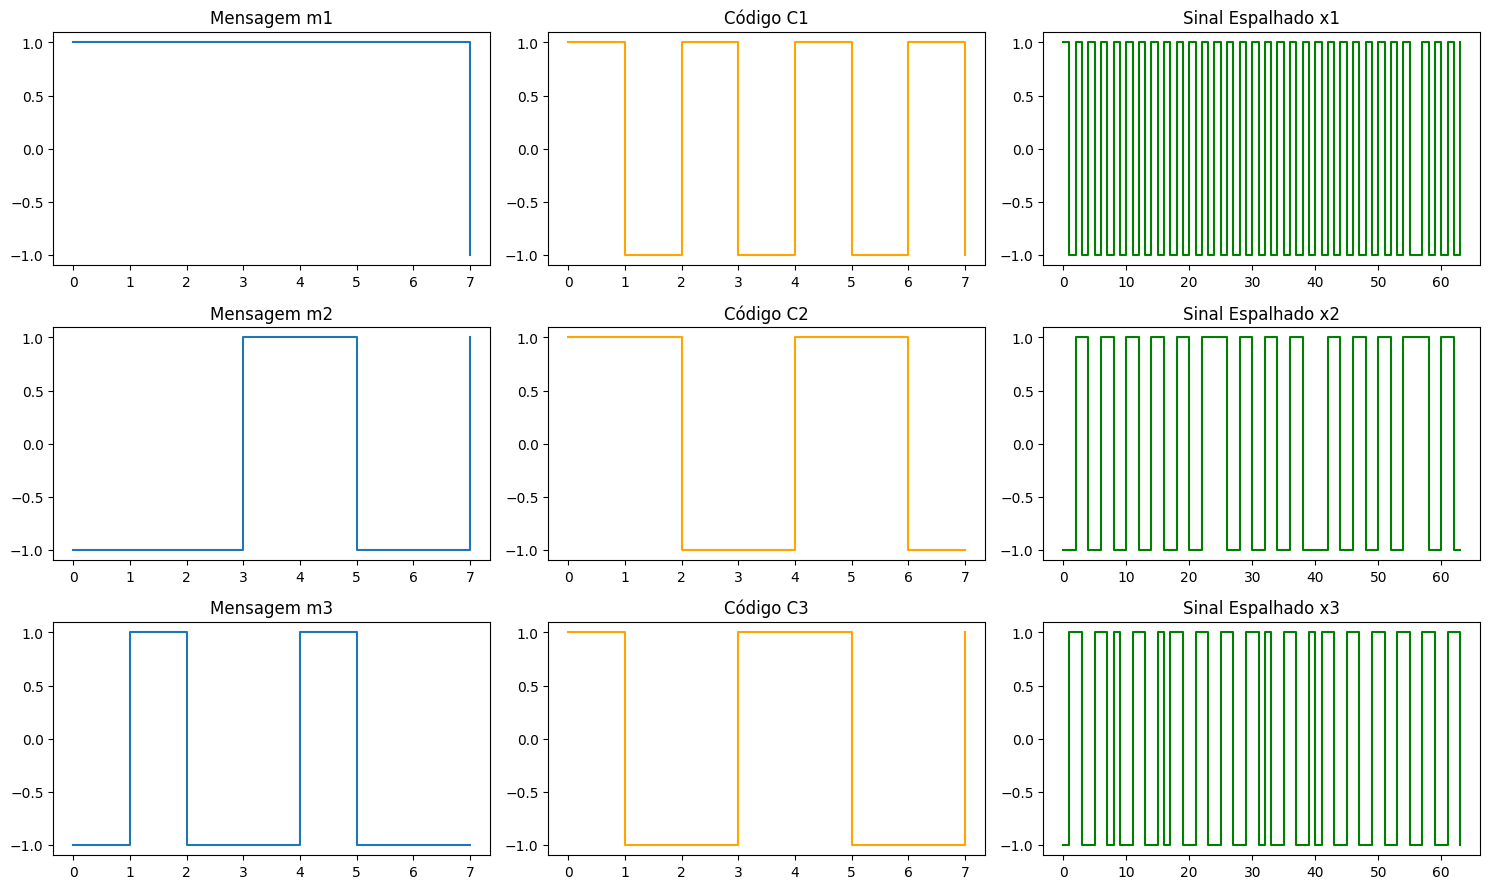

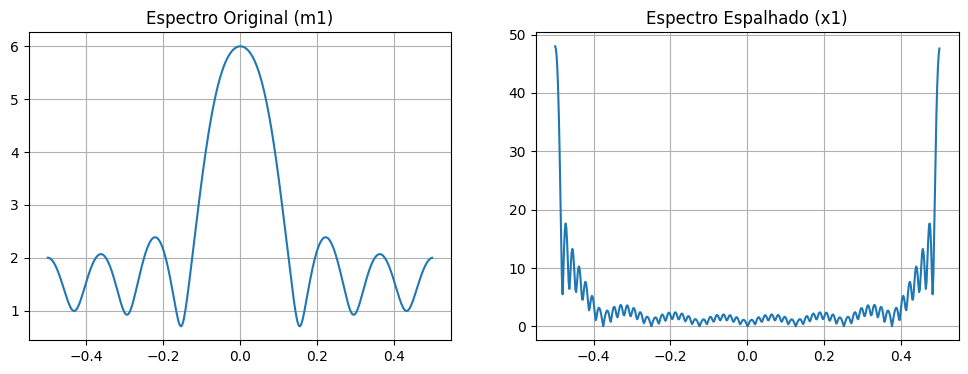

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
from scipy.fft import fft, fftshift

# (a) Configuração e Espalhamento
L = 8
N_bits = 8
rng = np.random.default_rng(7)

messages = rng.choice([-1, 1], size=(3, N_bits))
H = hadamard(L)
codes = H[1:4, :] # Três códigos ortogonais

# Codificação (Produto de Kronecker para espalhar os bits)
x = np.array([np.kron(messages[k], codes[k]) for k in range(3)])

# Visualização dos Sinais
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for k in range(3):
    axes[k, 0].step(range(N_bits), messages[k], where='post')
    axes[k, 0].set_title(f'Mensagem m{k+1}')
    axes[k, 1].step(range(L), codes[k], where='post', color='orange')
    axes[k, 1].set_title(f'Código C{k+1}')
    axes[k, 2].step(range(N_bits*L), x[k], where='post', color='green')
    axes[k, 2].set_title(f'Sinal Espalhado x{k+1}')
plt.tight_layout()
plt.show()

# Espectro
def plot_spectrum(sig, title, ax):
    N_fft = 512
    X = fftshift(fft(sig, N_fft))
    f = np.linspace(-0.5, 0.5, N_fft)
    ax.plot(f, np.abs(X))
    ax.set_title(title)
    ax.grid(True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_spectrum(messages[0], 'Espectro Original (m1)', axes[0])
plot_spectrum(x[0], 'Espectro Espalhado (x1)', axes[1])
plt.show()

**Comentário (a):** A codificação de Hadamard multiplica cada bit por uma sequência de 'chips' mais rápida. No domínio da frequência, isso resulta no espalhamento do espectro (spread spectrum), reduzindo a densidade de potência mas ocupando uma largura de banda muito maior.

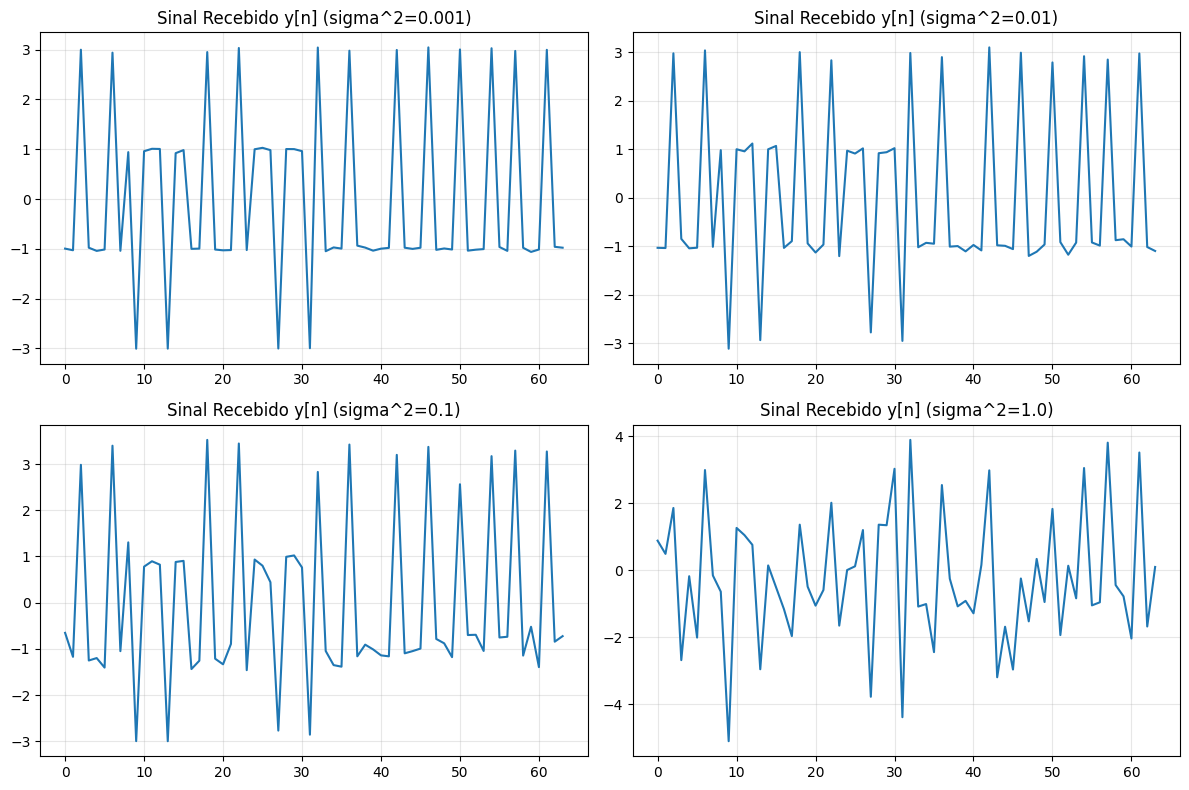

In [10]:
# (b) Sinal Recebido com Ruído AWGN
sigma2_vals = [1e-3, 1e-2, 1e-1, 1.0]
signal_sum = np.sum(x, axis=0)

plt.figure(figsize=(12, 8))
for i, s2 in enumerate(sigma2_vals):
    noise = rng.normal(0, np.sqrt(s2), signal_sum.shape)
    y = signal_sum + noise
    plt.subplot(2, 2, i+1)
    plt.plot(y)
    plt.title(f'Sinal Recebido y[n] (sigma^2={s2})')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (c) Recuperação Matemática
A recuperação é feita via correlação. Para o usuário $k$:
$$\hat{m}_k = \text{sign}\left( \frac{1}{L} \mathbf{Y} \mathbf{c}_k^T \right)$$
Onde $\mathbf{Y}$ é a matriz do sinal recebido particionada em blocos de tamanho $L$. Como os códigos são ortogonais ($\mathbf{c}_i \mathbf{c}_j^T = L \delta_{ij}$), o ruído $w[n]$ é atenuado pelo processo de desespalhamento (integração).

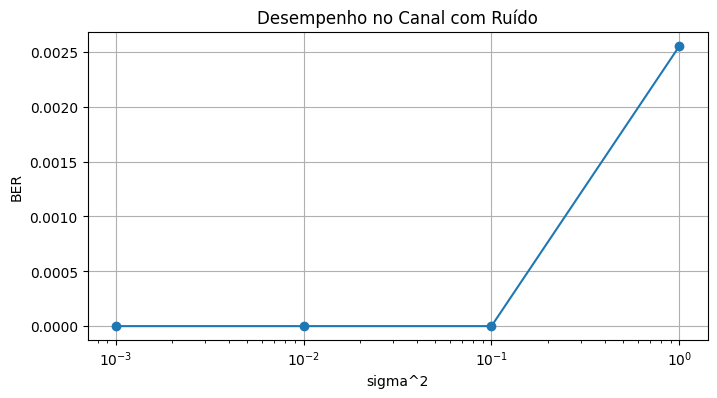

In [11]:
# (d) Simulação Monte Carlo - BER vs AWGN
def run_ber_sim_awgn(num_bits, trials, s2_list):
    ber_list = []
    for s2 in s2_list:
        errors = 0
        for _ in range(trials):
            m_test = rng.choice([-1, 1], size=(3, num_bits))
            y_clean = np.sum([np.kron(m_test[k], codes[k]) for k in range(3)], axis=0)
            y_noisy = y_clean + rng.normal(0, np.sqrt(s2), y_clean.shape)

            # Decodificação
            y_reshaped = y_noisy.reshape((num_bits, L))
            m_hat = np.sign(y_reshaped @ codes.T).T
            errors += np.sum(m_hat != m_test)
        ber_list.append(errors / (3 * num_bits * trials))
    return ber_list

ber_awgn = run_ber_sim_awgn(100, 500, sigma2_vals)

plt.figure(figsize=(8, 4))
plt.semilogx(sigma2_vals, ber_awgn, 'o-', label='Prob. Erro (AWGN)')
plt.xlabel('sigma^2')
plt.ylabel('BER')
plt.title('Desempenho no Canal com Ruído')
plt.grid(True)
plt.show()

### (e) Distorção no Código
Se o receptor usa $\hat{C} = C + W$, o desespalhamento torna-se:
$$\text{sign}( (X + 0) (C + W)^T ) = \text{sign}( X C^T + X W^T )$$
Mesmo sem ruído no canal, o termo $X W^T$ (interferência gerada pela distorção do código) pode causar erros de decisão, pois quebra a ortogonalidade perfeita no receptor.

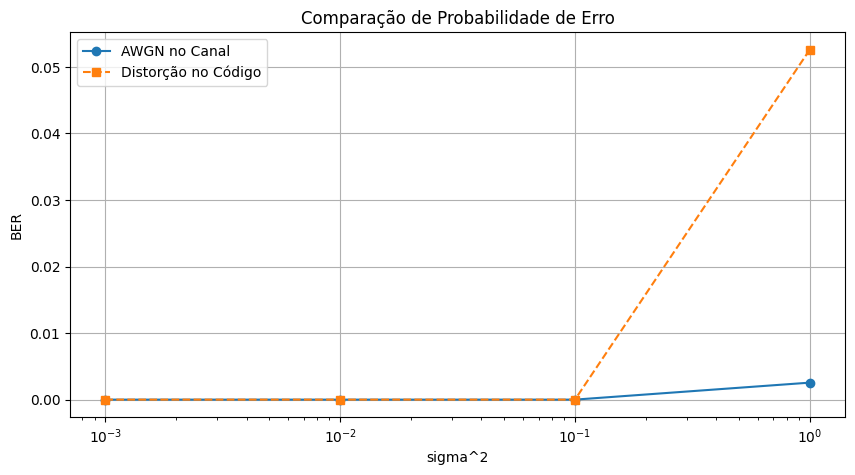

In [12]:
# (f) Simulação Monte Carlo - BER vs Distorção de Código
def run_ber_sim_distort(num_bits, trials, s2_list):
    ber_list = []
    for s2 in s2_list:
        errors = 0
        for _ in range(trials):
            m_test = rng.choice([-1, 1], size=(3, num_bits))
            y_clean = np.sum([np.kron(m_test[k], codes[k]) for k in range(3)], axis=0)

            # Receptor com código ruidoso
            codes_distorted = codes + rng.normal(0, np.sqrt(s2), codes.shape)

            y_reshaped = y_clean.reshape((num_bits, L))
            m_hat = np.sign(y_reshaped @ codes_distorted.T).T
            errors += np.sum(m_hat != m_test)
        ber_list.append(errors / (3 * num_bits * trials))
    return ber_list

ber_distort = run_ber_sim_distort(100, 500, sigma2_vals)

plt.figure(figsize=(10, 5))
plt.semilogx(sigma2_vals, ber_awgn, 'o-', label='AWGN no Canal')
plt.semilogx(sigma2_vals, ber_distort, 's--', label='Distorção no Código')
plt.xlabel('sigma^2')
plt.ylabel('BER')
plt.title('Comparação de Probabilidade de Erro')
plt.legend()
plt.grid(True)
plt.show()